In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [3]:
df = pd.read_csv('C:\\Users\\lappixel\\Desktop\\python projects\\machine learning\\practice\\1632300362534233.csv')

df.head()


,Area,Room,Parking,Warehouse,Elevator,Address,Price,PriceUSD
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [5]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(3479, 8)
Area          object
Room           int64
Parking         bool
Warehouse       bool
Elevator        bool
Address       object
Price        float64
PriceUSD     float64
dtype: object
Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address      23
Price         0
PriceUSD      0
dtype: int64


In [7]:
df['Area'] = df['Area'].astype(str).str.replace(',', '').str.strip()
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

In [11]:
df = df.dropna(subset=['Address'])

In [17]:
df = df[df['Area'] < 500]

In [19]:
df = df.dropna()

In [26]:
df.describe()

,Area,Room,Price,PriceUSD
count,3429.000000,3429.000000,3.429000e+03,3.429000e+03
mean,103.556139,2.072908,5.190088e+09,1.730029e+05
std,53.956064,0.746398,7.321461e+09,2.440487e+05
min,30.000000,0.000000,3.600000e+06,1.200000e+02
25%,68.000000,2.000000,1.400000e+09,4.666667e+04
50%,90.000000,2.000000,2.850000e+09,9.500000e+04
75%,120.000000,2.000000,6.000000e+09,2.000000e+05
max,465.000000,5.000000,9.240000e+10,3.080000e+06


In [28]:
df = df[df['Room'] > 0]

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

df = df[df['Price'] <= Q3 + 1.5 * IQR]
df = df[df['Price'] >= Q1 - 1.5 * IQR]

print(df.shape)
print(df['Price'].describe())

(3121, 8)
count    3.121000e+03
mean     3.455015e+09
std      2.886691e+09
min      3.600000e+06
25%      1.280000e+09
50%      2.500000e+09
75%      4.600000e+09
max      1.285000e+10
Name: Price, dtype: float64


In [30]:
msk = np.random.rand(len(df)) < 0.8
train = df[msk]
test = df[~msk]

print("train:", len(train))
print("test:", len(test))

train: 2483
test: 638


In [32]:
features = ['Area', 'Room', 'Parking', 'Warehouse', 'Elevator']

regr = linear_model.LinearRegression()

x_train = np.asanyarray(train[features].astype(float))
y_train = np.asanyarray(train[['Price']])

regr.fit(x_train, y_train)

print('Coefficients: ', regr.coef_)
print('Intercept: ', regr.intercept_)

Coefficients:  [[3.52508634e+07 6.06738289e+08 7.85790543e+08 6.36831347e+08
  7.58624755e+08]]
Intercept:  [-2.84603156e+09]


In [36]:
x_test = np.asanyarray(test[features].astype(float))
y_test = np.asanyarray(test[['Price']])

y_hat = regr.predict(x_test)

print("MSE: %.2f" % np.mean((y_hat - y_test) ** 2))
print("Variance score: %.2f" % regr.score(x_test, y_test))

MSE: 4917229756837712896.00
Variance score: 0.38


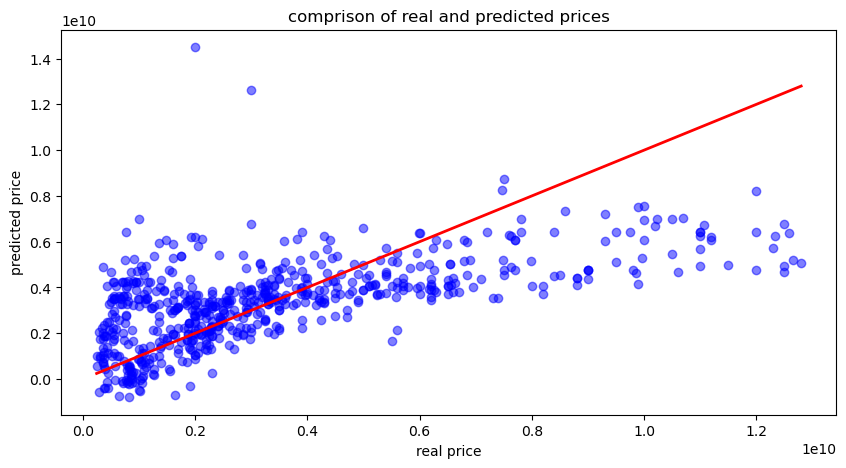

In [46]:
plt.figure(figsize=(10, 5))

plt.scatter(y_test, y_hat, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         '-r', linewidth=2)

plt.xlabel("real price")
plt.ylabel("predicted price")
plt.title("comprison of real and predicted prices")
plt.show()

In [50]:
sample = [[120, 3, True, True, True]]
sample_array = np.asanyarray(sample, dtype=float)
print(sample_array)
predicted_price = regr.predict(sample_array)
print(f"price: {predicted_price[0][0]:,.0f} ")

[[120.   3.   1.   1.   1.]]
price: 5,385,533,564 
